# Case Study by CFI - Portfolio Optimization 
In this case study, I'll build two $10,000 portfolios with four stocks. The first will have equal weighting, while the second will be optimized for the best return adjusted for risk. The process involves:

Importing two years of stock data
Building the initial equal-weighted portfolio
Analyzing and visualizing it
Generating 10,000 random portfolio scenarios
Identifying and visualizing the optimal portfolio

## Import Packages & Connect to Data

In [158]:
# Import packages needed for case study
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [159]:
# List the four stock ticker symbols for our portfolio
stock_list = ['AMD', 'AAPL', 'MSFT', 'ORCL']

# Create an empty dictionary to store our stock info
stocks = {}

# Loop through each stock in the stock_list
for i_stock in stock_list:
    stocks[i_stock] = pd.read_csv(str(i_stock + '.csv'), parse_dates=True, index_col = 'Date')

In [160]:
# Examine the 'AMD' Adj Close from the stocks dictionary
stocks['AAPL'].head()

,Adj Close
Date,
2019-01-02,38.047047
2019-01-03,34.257271
2019-01-04,35.719696
2019-01-07,35.640198
2019-01-08,36.319611


## Create the Equal-Weighted Portfolio
To create the equal-weighted portfolio, it need to add some additional columns to the DataFrames in the `stocks` dictionary.
* Normalized Return = Adjusted Close / Adjusted Close on the `startdate` of the portfolio
* Allocation = Normalized Return * 0.25 (equal weighting for each of the four stocks)
* Position Value = Allocation * 10,000 (value of the portfolio)

In [161]:
# Create 'Normalized Return' column for each stock
for stock_name, stock_data in stocks.items():
    first_adj_close = stock_data.iloc[0]['Adj Close'] # Select the first row from the Adj Close column
    stock_data['Normalized Return'] = stock_data['Adj Close'] / first_adj_close

In [162]:
stocks['AAPL'].head()

,Adj Close,Normalized Return
Date,,
2019-01-02,38.047047,1.000000
2019-01-03,34.257271,0.900392
2019-01-04,35.719696,0.938830
2019-01-07,35.640198,0.936740
2019-01-08,36.319611,0.954597


In [163]:
# Create allocation for each stock - equally weighted in our initial portfolio
for stock_name, stock_data in stocks.items():
    stock_data['Allocation'] = stock_data['Normalized Return'] * 0.25

In [164]:
stocks['AAPL'].head()

,Adj Close,Normalized Return,Allocation
Date,,,
2019-01-02,38.047047,1.000000,0.250000
2019-01-03,34.257271,0.900392,0.225098
2019-01-04,35.719696,0.938830,0.234707
2019-01-07,35.640198,0.936740,0.234185
2019-01-08,36.319611,0.954597,0.238649


In [165]:
# Set the value of the portfolio to $10k
for stock_name, stock_data in stocks.items():
    stock_data['Position Value'] = stock_data['Allocation'] * 10000

In [166]:
stocks['MSFT'].head()

,Adj Close,Normalized Return,Allocation,Position Value
Date,,,,
2019-01-02,96.632668,1.000000,0.250000,2500.000000
2019-01-03,93.077728,0.963212,0.240803,2408.029568
2019-01-04,97.406723,1.008010,0.252003,2520.025720
2019-01-07,97.530945,1.009296,0.252324,2523.239483
2019-01-08,98.238113,1.016614,0.254153,2541.534760


## Visualize the Portfolio Performance
Create two line charts that show the return of the portfolio, and the return of the individual stocks, over time.

In [167]:
# Create position_values dictionary
position_values = {}

for stock_name, stock_data in stocks.items():
    position_values[stock_name] = stock_data['Position Value']

In [168]:
# Convert the position_values dictionary to a DataFrame
position_values = pd.DataFrame(data=position_values)
position_values.head()

,AMD,AAPL,MSFT,ORCL
Date,,,,
2019-01-02,2500.000000,2500.000000,2500.000000,2500.000000
2019-01-03,2263.674895,2250.980945,2408.029568,2475.674577
2019-01-04,2522.570377,2347.074161,2520.025720,2582.374925
2019-01-07,2731.014309,2341.850477,2523.239483,2623.286049
2019-01-08,2754.912385,2386.493420,2541.534760,2647.059250


In [169]:
# Add 'Total' column to position values, summing the other columns
position_values['Total'] = position_values.sum(axis=1)
position_values.head()

,AMD,AAPL,MSFT,ORCL,Total
Date,,,,,
2019-01-02,2500.000000,2500.000000,2500.000000,2500.000000,10000.000000
2019-01-03,2263.674895,2250.980945,2408.029568,2475.674577,9398.359984
2019-01-04,2522.570377,2347.074161,2520.025720,2582.374925,9972.045182
2019-01-07,2731.014309,2341.850477,2523.239483,2623.286049,10219.390319
2019-01-08,2754.912385,2386.493420,2541.534760,2647.059250,10329.999814


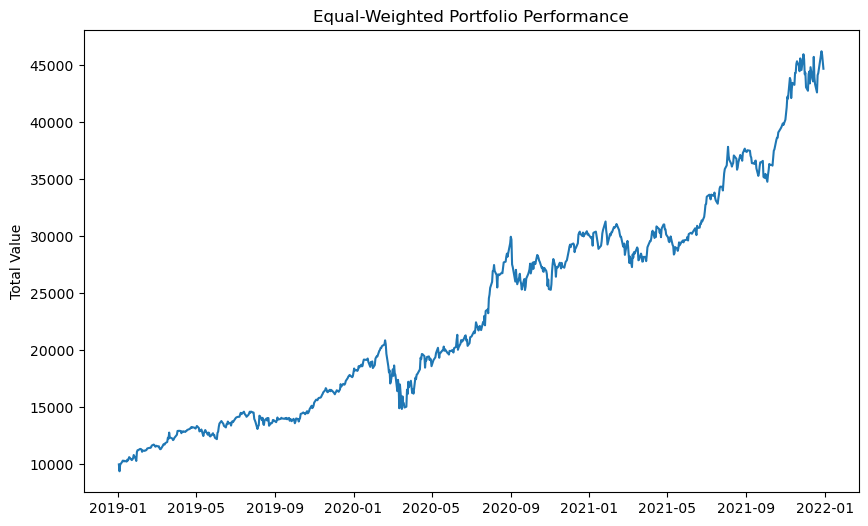

In [170]:
# View the total portfolio
plt.figure(figsize=(10, 6))

plt.plot(position_values['Total'])

plt.title('Equal-Weighted Portfolio Performance')
plt.ylabel('Total Value');

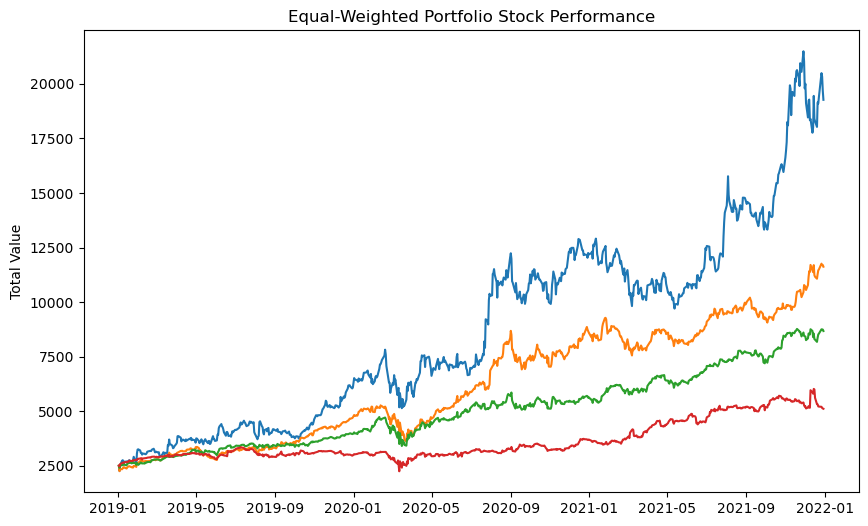

In [171]:
# View the four stocks in the portfolio
plt.figure(figsize=(10, 6))

plt.plot(position_values.iloc[:,0:4])

plt.title('Equal-Weighted Portfolio Stock Performance')
plt.ylabel('Total Value');

## Calculate Performance Metrics for the Portfolio

 * Cumulative Return
 * Mean Daily Return
 * Standard Deviation Daily Return
 * Sharpe Ratio
 * Annualized Sharpe Ratio

In [172]:
# Define the end and start value of the portfolio
end_value = position_values['Total'][-1]
start_value = position_values['Total'][0]

# Calculate the cumulative portfolio return as a percentage
cumulative_return = end_value / start_value - 1

print(f"The cumulative portfolio return as a percentage is: {round(cumulative_return*100,2)}%")

The cumulative portfolio return as a percentage is: 346.84%


C:\Users\alikp\AppData\Local\Temp\ipykernel_9856\3463157618.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  end_value = position_values['Total'][-1]
C:\Users\alikp\AppData\Local\Temp\ipykernel_9856\3463157618.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  start_value = position_values['Total'][0]


In [173]:
# Create a 'Daily Returns' column
position_values['Daily Return'] = position_values['Total'].pct_change()
position_values.head()

,AMD,AAPL,MSFT,ORCL,Total,Daily Return
Date,,,,,,
2019-01-02,2500.000000,2500.000000,2500.000000,2500.000000,10000.000000,NaN
2019-01-03,2263.674895,2250.980945,2408.029568,2475.674577,9398.359984,-0.060164
2019-01-04,2522.570377,2347.074161,2520.025720,2582.374925,9972.045182,0.061041
2019-01-07,2731.014309,2341.850477,2523.239483,2623.286049,10219.390319,0.024804
2019-01-08,2754.912385,2386.493420,2541.534760,2647.059250,10329.999814,0.010823


In [174]:
# Calculate the mean Daily Return 
mean_daily_return = position_values['Daily Return'].mean()
print(f"The mean daily return is: {round(mean_daily_return,4)}")

The mean daily return is: 0.0022


In [175]:
# Calculate the standard deviation of Daily Return 
std_daily_return = position_values['Daily Return'].std()
print(f"The std daily return is: {round(std_daily_return,4)}")

The std daily return is: 0.0207


### Sharpe Ratio
It is calculated by the average return of the portfolio minus a risk free rate (such as government bonds), divided by the standard deviation of the return. In this case, assuming the risk-free rate is close to zero, so won't add it to the formula.

In [176]:
# Calculate the sharpe ratio
sharpe_ratio = mean_daily_return / std_daily_return
sharpe_ratio

0.1063111914002701

In [177]:
# Calculate the annualized sharpe ratio
sharpe_ratio_annualized = sharpe_ratio * 252**0.5
sharpe_ratio_annualized

1.6876378441686195

## Prepare Scenarios to Optimize Portfolio Weighting

 * Create a dictionary containing the adjusted close for each of our stocks: stock_adj_close
 * Create another dictionary that transforms the adjusted close for each day to a percent change from the previous day

In [178]:
# Create stock_adj_close dictionary
stock_adj_close = {}

for stock_name, stock_data in stocks.items():
    stock_adj_close[stock_name] = stock_data['Adj Close']

In [179]:
# Convert the stock_adj_close dictionary to a DataFrame
stock_adj_close = pd.DataFrame(data=stock_adj_close)
stock_adj_close.head()

,AMD,AAPL,MSFT,ORCL
Date,,,,
2019-01-02,18.830000,38.047047,96.632668,42.138145
2019-01-03,17.049999,34.257271,93.077728,41.728134
2019-01-04,19.000000,35.719696,97.406723,43.526596
2019-01-07,20.570000,35.640198,97.530945,44.216164
2019-01-08,20.750000,36.319611,98.238113,44.616867


In [180]:
# Create stock_returns DataFrames to see the day over day change in stock value
stock_returns = stock_adj_close.pct_change()
stock_returns.head()

,AMD,AAPL,MSFT,ORCL
Date,,,,
2019-01-02,NaN,NaN,NaN,NaN
2019-01-03,-0.094530,-0.099608,-0.036788,-0.009730
2019-01-04,0.114370,0.042689,0.046509,0.043100
2019-01-07,0.082632,-0.002226,0.001275,0.015842
2019-01-08,0.008751,0.019063,0.007251,0.009062


## Build & Run 10,000 Portfolio Scenarios
Use the `numpy.zeros()` function to build the structures required to generate these scenarios and store the output. 

This function creates arrays that are filled with zeros(_create the arrays with zeros first is to give our arrays the correct shape before replacing them with the correct value_).

 * weights_array - this array will have 10,000 rows and 4 columns and hold the weighting allocation for each stock
 * returns_array - this array will contain the portfolio return for each scenario
 * volatility_array - this array will contain the portfolio volatility for each scenario
 * sharpe_array - this array will contain the sharpe ratio for each scenario

In [181]:
# Define the number of scenarios and create a blank array to populate stock weightings for each scenario
scenarios = 10000

weights_array = np.zeros((scenarios, len(stock_returns.columns)))

weights_array

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       ...,
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

In [182]:
# Create additional blank arrays for scenario output
returns_array = np.zeros(scenarios)
volatility_array = np.zeros(scenarios)
sharpe_array = np.zeros(scenarios)

In [183]:
import random
random.seed(3)
np.random.seed(3)

for index in range(scenarios): 
    # Generate four random numbers for each index
    numbers = np.array(np.random.random(4))
    
    # Divide each number by the sum of the numbers to generate the random weight
    weights = numbers / np.sum(numbers)
    
    # Save the weights in weights_array
    weights_array[index,:] = weights
    
    # Calculate the return for each scenario
    returns_array[index] = np.sum(stock_returns.mean()*252*weights)
    
    # Calculate the expected volatility for each scenario
    volatility_array[index] = np.sqrt(np.dot(weights.T,np.dot(stock_returns.cov()*252, weights)))

    # Calculate the Sharpe Ratio for each scenario 
    sharpe_array[index] = returns_array[index] / volatility_array[index]
    
print(f"The first combination: {weights_array[0]}")
print(f"The sharpe ratio of the first portfolio: {sharpe_array[0]}")

The first combination: [0.26728964 0.34364796 0.14116943 0.24789297]
The sharpe ratio of the first portfolio: 1.774433215177886


## Identify the Optimal Portfolio

In [184]:
# Find the highest sharpe ratio in sharpe_array
sharpe_array.max()

1.832310212575708

In [185]:
# Find the index of the optimal portfolio
index_max_sharpe = sharpe_array.argmax()
index_max_sharpe

8746

In [186]:
# Print the optimal weights for each stock

print(f"The optimal weights for each stock: {stock_list}{weights_array[index_max_sharpe,:] }")

The optimal weights for each stock: ['AMD', 'AAPL', 'MSFT', 'ORCL'][0.29761151 0.55853186 0.13323304 0.0106236 ]


## Visualize the Optimal Portfolio & Portfolio Scenarios

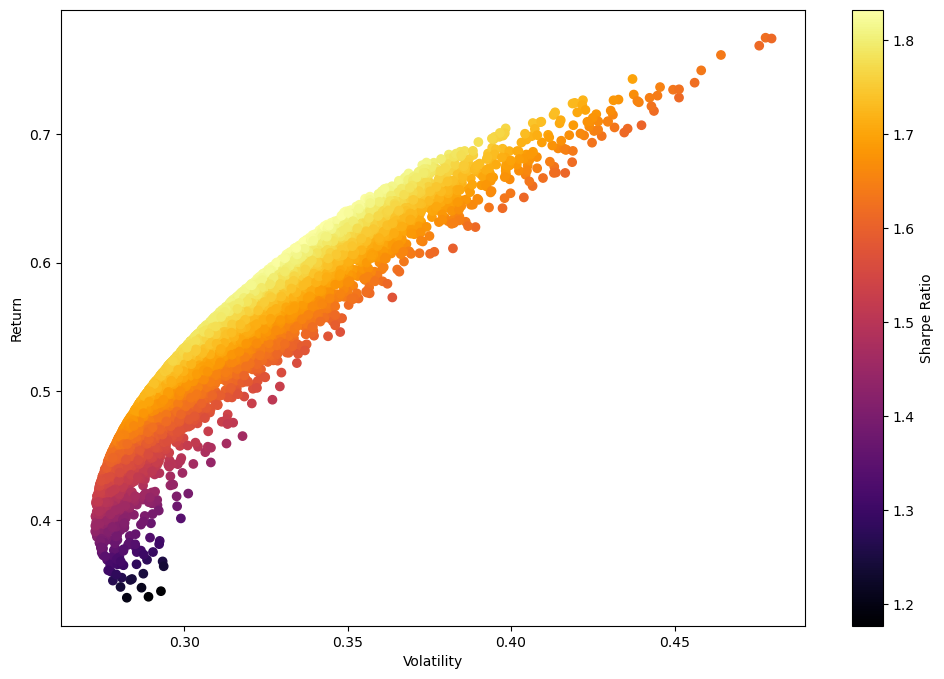

In [187]:
# Visualize volatility vs returns for each scenario
plt.figure(figsize=(12,8))

plt.scatter(volatility_array, returns_array, c=sharpe_array, cmap='inferno')

plt.colorbar(label='Sharpe Ratio')
plt.xlabel('Volatility')
plt.ylabel('Return');

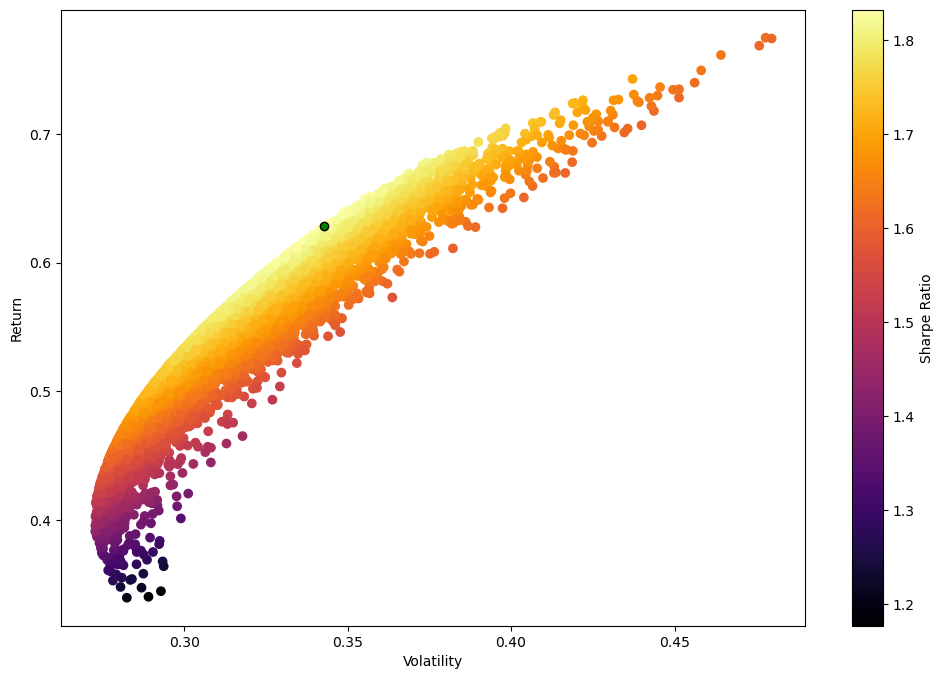

In [188]:
# Identify the optimal portfolio in the returns and volatility arrays
max_sharpe_return = returns_array[index_max_sharpe]
max_sharpe_volatility = volatility_array[index_max_sharpe]

# Visualize volatility vs returns for each scenario
plt.figure(figsize=(12,8))

plt.scatter(volatility_array, returns_array, c=sharpe_array, cmap='inferno')

plt.colorbar(label='Sharpe Ratio')
plt.xlabel('Volatility')
plt.ylabel('Return')

# Add the optimal portfolio to the visual
plt.scatter(max_sharpe_volatility, max_sharpe_return, c='green', edgecolors='black');